### 2_2 - Train based only geometric + semantic of query column

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv('ds/cleaned_amazon_queries_dataset_en_50k_geo_semant.csv')
x = data.drop(columns=['query' , 'Unnamed: 0'])

In [3]:
x.head(3)

,query_chars,query_words,contains_digit,digit_count,avg_word_len,space_count,spec_char_count,emb_0,emb_1,emb_2,...,emb_40,emb_41,emb_42,emb_43,emb_44,emb_45,emb_46,emb_47,emb_48,emb_49
0,-0.651438,-0.917934,-0.419985,-0.365241,1.004975,-0.913646,-0.201665,-0.028869,0.041391,0.147372,...,-0.091584,0.011627,0.097332,0.024175,-0.122666,0.036653,-0.021834,-0.018718,-0.050285,-0.045307
1,-0.250755,-0.346518,-0.419985,-0.365241,0.160833,-0.345260,-0.201665,0.040609,-0.083417,-0.033752,...,-0.046814,0.022521,0.077184,0.015270,-0.049487,0.060322,-0.030696,0.007400,0.087071,-0.105523
2,-0.851779,-0.346518,-0.419985,-0.365241,-1.286269,-0.345260,-0.201665,-0.052110,0.212552,-0.001981,...,-0.040206,-0.162135,0.078060,0.077822,-0.008254,-0.028601,0.086238,0.023818,0.012644,0.042072


#### Kmeans

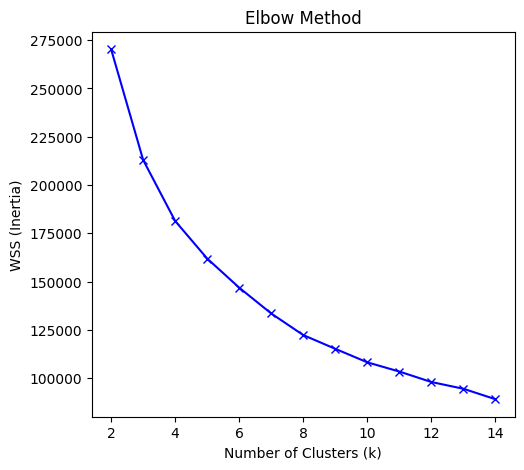

In [ ]:
#elbow method to find best k

wss = []
silhouette_avg = []
k_range = range(2, 15) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(x)
    
    #  WSS for Elbow
    wss.append(kmeans.inertia_)
    

# Plotting the results for your paper
plt.figure(figsize=(12, 5))

# Plot Elbow
plt.subplot(1, 2, 1)
plt.plot(k_range, wss, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WSS (Inertia)')
plt.title('Elbow Method')


plt.show()


#no clear point

In [6]:
#find k based on silhouette_score

import numpy as np

#to make it fast
sample_idx = np.random.choice(len(x), size=5000, replace=False)
x_sample = x.iloc[sample_idx]

for k in range(2, 10, 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = kmeans.fit_predict(x_sample)
    score = silhouette_score(x_sample, labels)

    print(k, score)


# best based on silhouette_score is k = 2

2 0.48501718914025915
3 0.36845718689232065
4 0.29941314703031985
5 0.24887212227131777
6 0.263446269062051
7 0.2580773142565897
8 0.2496574277716668
9 0.2679859236777797


In [7]:
#Kmeans Model 

kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)

# predict
data['kmeans_cluster'] = kmeans_final.fit_predict(x)

# check clusters
print(data['kmeans_cluster'].value_counts())

kmeans_cluster
0    42016
1     7984
Name: count, dtype: int64


In [11]:
for i in range(2):
    print(f"\n--- Examples of Cluster {i} ---")
    print(data[data['kmeans_cluster'] == i]['query'].head(10).values)


--- Examples of Cluster 0 ---
<StringArray>
[              'workout weights',           'nintendo gift cards',
                 'urban skin rx',                     'bird seed',
   '+foot cream without alcohol',                  'cpap filters',
 'long cord lavalier microphone',       'tumblers bulk wholesale',
            'carhartt lined cap',                'seat belt belt']
Length: 10, dtype: str

--- Examples of Cluster 1 ---
<StringArray>
[  'brother tn730 high yield black toner',
                              '60 lashes',
                          'iphone used 6',
                  'compost bags 3 gallon',
 '06 suzuki 600 side fairing not painted',
                          'ffp2 not kn95',
                     'rear rack duke 390',
            '0 size 4 pads without wings',
                         'diapers size 3',
                     '1 inch block heels']
Length: 10, dtype: str


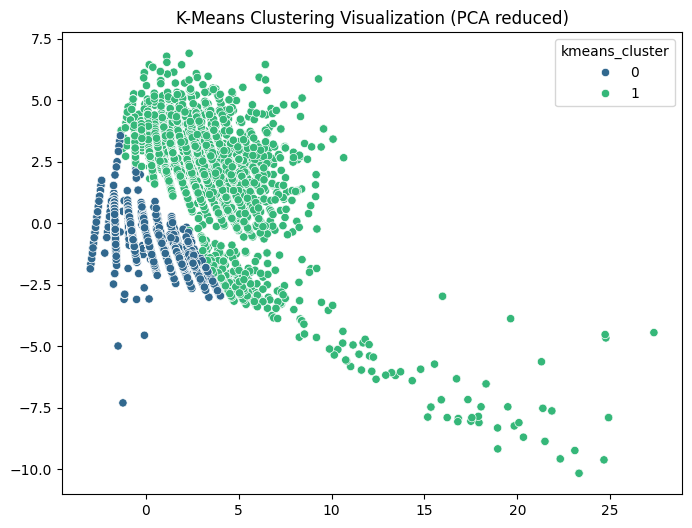

In [12]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=data['kmeans_cluster'], palette='viridis')
plt.title('K-Means Clustering Visualization (PCA reduced)')
plt.show()

In [13]:
#we can see that the cluster are based on geometric columns so we reweight or we give more importance to semantic

geo_cols = [
    'query_chars', 'query_words', 'contains_digit',
    'digit_count', 'avg_word_len', 'space_count', 'spec_char_count'
]

emb_cols = [c for c in x.columns if c.startswith('emb_')]

#adjust weights
geo_weight = 0.2
emb_weight = 3.0

x_weighted = x.copy()

x_weighted[geo_cols] *= geo_weight
x_weighted[emb_cols] *= emb_weight

In [15]:
#find k based on silhouette_score

import numpy as np

#to make it fast
sample_idx = np.random.choice(len(x_weighted), size=5000, replace=False)
x_sample = x.iloc[sample_idx]

for k in range(2, 10, 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = kmeans.fit_predict(x_sample)
    score = silhouette_score(x_sample, labels)

    print(k, score)


# best based on silhouette_score is k = 2

2 0.48067229724936916
3 0.30527153995555817
4 0.30817616936350134
5 0.2694034896946068
6 0.2605044757039041
7 0.2569037529059038
8 0.2632842766388228
9 0.22263061538635684


In [ ]:
#Kmeans Model 

kmeans_final2 = KMeans(n_clusters=3, random_state=42, n_init=10)

# predict
data['kmeans2_cluster'] = kmeans_final2.fit_predict(x_weighted)

# check clusters
print(data['kmeans2_cluster'].value_counts())


for i in range(3):
    print(f"\n--- Examples of Cluster {i} ---")
    print(data[data['kmeans2_cluster'] == i]['query'].head(5).values)

#after giving importance to semantic columns and as much as you add k cluster it will categorise more precisly the queries 
#like now cluster 0 general products  , cluster 1 dress and cloths , cluster 2 tools and equipement

kmeans2_cluster
2    20168
0    19969
1     9863
Name: count, dtype: int64

--- Examples of Cluster 0 ---
<StringArray>
[            'workout weights',         'nintendo gift cards',
               'urban skin rx',                   'bird seed',
 '+foot cream without alcohol']
Length: 5, dtype: str

--- Examples of Cluster 1 ---
<StringArray>
['hot pink berets for women',             'black zipties',
            'white headband',       'women's dress socks',
     'orange shirts for men']
Length: 5, dtype: str

--- Examples of Cluster 2 ---
<StringArray>
['brother tn730 high yield black toner',
                         'cpap filters',
        'long cord lavalier microphone',
              'tumblers bulk wholesale',
                   'carhartt lined cap']
Length: 5, dtype: str


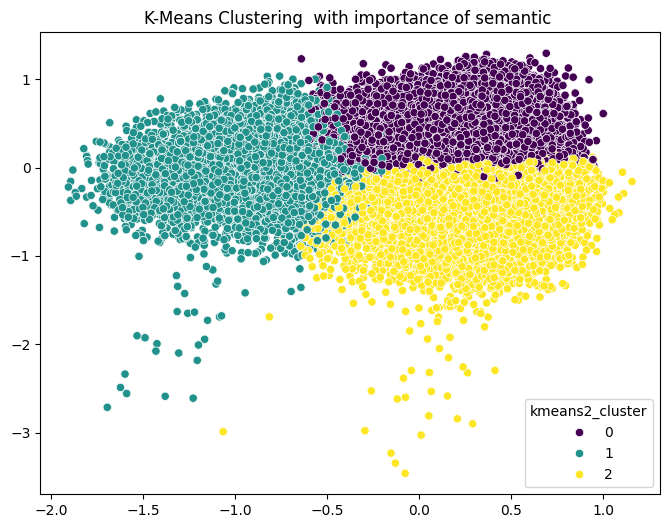

In [20]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_weighted)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=data['kmeans2_cluster'], palette='viridis')
plt.title('K-Means Clustering  with importance of semantic ')
plt.show()

#### GMM

In [24]:
from sklearn.mixture import GaussianMixture

#gmm model
gmm = GaussianMixture(n_components=3, random_state=42)


data['gmm_cluster'] = gmm.fit_predict(x_weighted)


for i in range(3):
    print(f"\n--- GMM Cluster {i} ---")
    print(data[data['gmm_cluster'] == i]['query'].head(5).values)


--- GMM Cluster 0 ---
<StringArray>
[    'workout weights', 'nintendo gift cards',       'urban skin rx',
           'bird seed',        'cpap filters']
Length: 5, dtype: str

--- GMM Cluster 1 ---
<StringArray>
[         '+foot cream without alcohol',
 'brother tn730 high yield black toner',
                            '60 lashes',
                        'iphone used 6',
                'compost bags 3 gallon']
Length: 5, dtype: str

--- GMM Cluster 2 ---
<StringArray>
[  'women's dress socks', 'orange shirts for men',        'diapers size 3',
  'plade shirts for men',      '6month baby toys']
Length: 5, dtype: str


In [25]:
# probability 
probs = gmm.predict_proba(x_weighted)

data['gmm_confidence'] = probs.max(axis=1)

print(data[['query', 'gmm_cluster', 'gmm_confidence']].head(10))

                                  query  gmm_cluster  gmm_confidence
0                       workout weights            0             1.0
1                   nintendo gift cards            0             1.0
2                         urban skin rx            0             1.0
3                             bird seed            0             1.0
4           +foot cream without alcohol            1             1.0
5  brother tn730 high yield black toner            1             1.0
6                             60 lashes            1             1.0
7                          cpap filters            0             1.0
8         long cord lavalier microphone            0             1.0
9               tumblers bulk wholesale            0             1.0


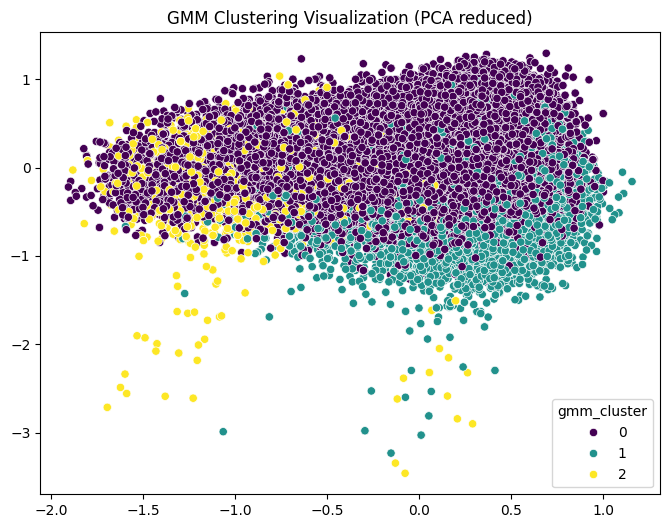

In [26]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_weighted)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=data['gmm_cluster'], palette='viridis')
plt.title('GMM Clustering Visualization (PCA reduced)')
plt.show()

#### DBscan

In [28]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

In [29]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.2,min_samples=10 , metric='euclidean'
)

labels = dbscan.fit_predict(x_weighted)

data['db_cluster'] = labels


print(data['db_cluster'].value_counts())

for c in sorted(data['db_cluster'].unique()):
    print("\n Cluster", c)
    print(data[data['db_cluster'] == c]['query'].head(5).tolist())

db_cluster
-1      43524
 10       695
 0        673
 12       641
 2        316
        ...  
 117        9
 149        9
 161        8
 113        8
 169        8
Name: count, Length: 175, dtype: int64

 Cluster -1
['workout weights', 'urban skin rx', 'bird seed', '+foot cream without alcohol', 'brother tn730 high yield black toner']

 Cluster 0
['iphone used 6', 'samsung galaxy a10', 'samsung galaxy note 10 case not plus', 'cell iphone 10', 'iphone 8 renewed att']

 Cluster 1
['orange shirts for men', 'plade shirts for men', 'mens goodthreads polo shirts', 'big and tall button down long sleeve shirts for men', 'mens t-shirts']

 Cluster 2
['6month baby toys', 'presents for boyfriends dad', 'best toys for 1 year old boy', 'gifts for 40 year old woman', '2 year baby girls toys disney']

 Cluster 3
['rose gold necklace', 'pearl silver lariat necklace', 'personalized necklace', 'cross necklace', 'new design necklace']

 Cluster 4
['midriff swimsuit for women', 'hot pink one piece swimsu

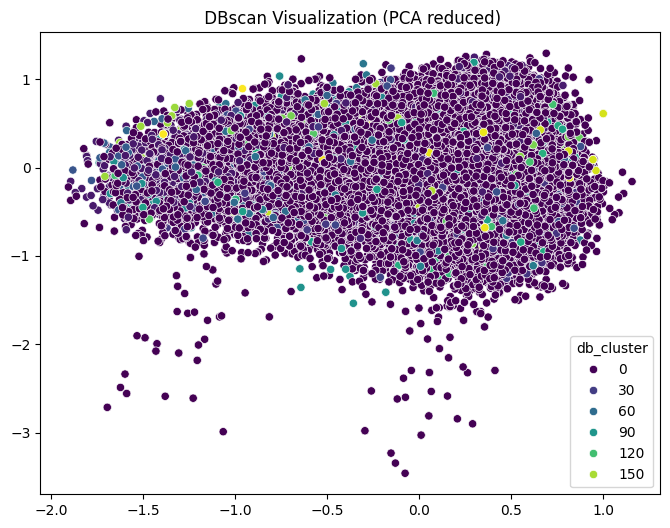

In [30]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_weighted)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=data['db_cluster'], palette='viridis')
plt.title(' DBscan Visualization (PCA reduced)')
plt.show()

### hdbscan

In [31]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=7,   
    min_samples=10,        
    metric='euclidean'
)

labels_hdb = clusterer.fit_predict(x_weighted)

data['hdbscan_cluster'] = labels_hdb

print(data['hdbscan_cluster'].value_counts())

for c in sorted(data['hdbscan_cluster'].unique()):
    print(f"\n HDBscan Cluster {c} ---")
    print(data[data['hdbscan_cluster'] == c]['query'].head(5).tolist())

hdbscan_cluster
 1    48153
-1     1811
 0       36
Name: count, dtype: int64

 HDBscan Cluster -1 ---
['06 suzuki 600 side fairing not painted', 'jewellery+box+small+crystal', "'oh no not you again' door mat", 'hummingbird feeders for outdoors glass', '10 lb resistance band without handles']

 HDBscan Cluster 0 ---
['I would purchase a laptop with good processing power, a RAM of above 10GB, a good video card, and good battery power.', "A Lenovo like mine its a little notebook it's fab. It would be black in colour ", 'A laptop which runs faster and has more capacity to run downloaded software ', "A Lenovo like mine its a little notebook it's fab. It would be black in colour ", 'Something that’s lightweight to carry and can be used to surf the internet and use Microsoft Office']

 HDBscan Cluster 1 ---
['workout weights', 'nintendo gift cards', 'urban skin rx', 'bird seed', '+foot cream without alcohol']


### evaluating

In [32]:
from sklearn.metrics import silhouette_score , calinski_harabasz_score , davies_bouldin_score
import numpy as np

In [34]:
#to calculate silhout scor fast
sample_idx = np.random.choice(len(x), size=5000, replace=False)
X_sample = x_weighted.iloc[sample_idx].values

models = {
    "kmeans": data['kmeans2_cluster'],
    "gmm": data['gmm_cluster'],
    "dbscan": data['db_cluster'],
    "hdbscan": data['hdbscan_cluster']
}

results = []

for name, column in models.items():
    
    labels = column.values
    X_values = x_weighted.values
    
    # noise remove dbscan and hdb
    mask = labels != -1
    
    # less clusters
    if len(set(labels[mask])) < 2:
        continue

    #  silhouette on 5k sam
    labels_sample = labels[sample_idx]
    mask_sample = labels_sample != -1
    
    if len(set(labels_sample[mask_sample])) > 1:
        sil = silhouette_score(
            X_sample[mask_sample],
            labels_sample[mask_sample]
        )
    else:
        sil = np.nan

    
    ch = calinski_harabasz_score(X_values[mask], labels[mask])
    db = davies_bouldin_score(X_values[mask], labels[mask])

    results.append({
        "model": name,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "n_clusters": len(set(labels[mask]))
    })

results_df = pd.DataFrame(results)
print(results_df)

     model  silhouette  calinski_harabasz  davies_bouldin  n_clusters
0   kmeans    0.042962        2143.956106        4.228121           3
1      gmm    0.036246         937.415147        4.142466           3
2   dbscan    0.162533          78.767989        1.324213         174
3  hdbscan    0.263085          89.350900        1.062665           2
